# Benchmark v5 — GPU — Tox21 — scaffold split, seed 1

**Task:** 12 binary toxicity assays (multi-label)
**Size:** ~7,831 molecules
**Metric:** Mean ROC-AUC ↑

**Scaffold split**, seed **1** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_1/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "tox21"
TASK_TYPE = "classification"
OUT_CHANNELS = 12
BATCH_SIZE = 128
GNN_EPOCHS = 80
LSTM_EPOCHS = 80
TOX21_TABULAR = True

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 10
print(f"GPU HPO tier: large — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 1

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: large — 10 trials, 80 epochs/trial, batch=128
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold
SPLIT_SEED=1  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv(DATA_DIR / "tox21.csv", na_values=["", " "])
smiles, y = preprocess_dataset(df, "tox21")
print(f"Molecules : {len(smiles)}")
print(f"Target shape: {y.shape}")
print(f"Missing fraction: {np.isnan(y).mean():.2%}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


[14:51:44] WARNING: not removing hydrogen atom without neighbors
[14:51:44] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:51:44] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:51:44] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:51:45] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:51:45] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:51:45] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:51:45] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:51:46] Explicit valence for atom # 20 Al, 6, is greater than permitted
INFO | [tox21] 7823 / 7831 valid molecules
[14:51:46] WARNING: not removing hydrogen atom without neighbors


Molecules : 7823
Target shape: (7823, 12)
Missing fraction: 17.06%


[14:51:59] WARNING: not removing hydrogen atom without neighbors


After bond filter: 7804 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


[14:52:02] WARNING: not removing hydrogen atom without neighbors
[14:52:18] WARNING: not removing hydrogen atom without neighbors
INFO | Loaded 7810 / 7823 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/tox21_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/splits/tox21_scaffold_splits.pkl
WARNING | 11 molecules in split have no 3D conformer (e.g. idx [217, 3445, 4930, 7312, 304]); excluded from 3D train/val/test subsets
WARNING | 1 molecules in split have no 3D conformer (e.g. idx [4863]); excluded from 3D train/val/test subsets
WARNING | 1 molecules in split have no 3D conformer (e.g. idx [3241]); excluded from 3D train/val/test subsets


3D graphs loaded: 7810 / 7804 (valid_idx mapping)
{'n_total': 7804, 'n_train': 6243, 'n_val': 780, 'n_test': 781, 'n_scaffolds_total': 2325, 'n_scaffolds_train': 764, 'n_scaffolds_val': 780, 'n_scaffolds_test': 781}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/10 (layers=3, hidden=192)


→ GIN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.3021 | val={'ROC-AUC': 0.6438790966716759, 'PRC-AUC': 0.24334817260896943}
INFO | HPO epoch   5/80 | loss=0.2047 | val={'ROC-AUC': 0.7126896986443344, 'PRC-AUC': 0.26728815118104254}
INFO | HPO epoch  10/80 | loss=0.1827 | val={'ROC-AUC': 0.7001383360999275, 'PRC-AUC': 0.29412956284028285}
INFO | HPO epoch  15/80 | loss=0.1749 | val={'ROC-AUC': 0.7057044661310531, 'PRC-AUC': 0.3041000797758057}
INFO | HPO epoch  20/80 | loss=0.1613 | val={'ROC-AUC': 0.7018813531156448, 'PRC-AUC': 0.2999783162818193}
INFO | Early stop at epoch 20 (patience=15)
INFO | GIN 2D HPO — trial 1/10 finished | val=-0.712690 | best=-0.712690
INFO | GIN 2D — starting trial 2/10 (layers=5, hidden=192)
INFO | HPO epoch   1/80 | loss=0.3665 | val={'ROC-AUC': 0.5877187889896104, 'PRC-AUC': 0.1805289387225952}
INFO | HPO epoch   5/80 | loss=0.2288 | val={'ROC-AUC': 0.6648119876560341, 'PRC-AUC': 0.2648123799909871}
INFO | HPO epoch  10/80 | loss=0.2053 | val={'ROC-AUC': 0.67823910000656

   scaffold test: {'ROC-AUC': 0.7111850871453459, 'PRC-AUC': 0.2968075207548368}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/10 (layers=3, hidden=192)


→ D-MPNN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.3258 | val={'ROC-AUC': 0.5733516722589446, 'PRC-AUC': 0.15428792823658916}
INFO | HPO epoch   5/80 | loss=0.2175 | val={'ROC-AUC': 0.6826333670268055, 'PRC-AUC': 0.24761374630829494}
INFO | HPO epoch  10/80 | loss=0.1967 | val={'ROC-AUC': 0.699748658796511, 'PRC-AUC': 0.26313481510028774}
INFO | HPO epoch  15/80 | loss=0.1870 | val={'ROC-AUC': 0.7065737301649815, 'PRC-AUC': 0.287575753686194}
INFO | HPO epoch  20/80 | loss=0.1793 | val={'ROC-AUC': 0.7084115624853348, 'PRC-AUC': 0.30026979388193037}
INFO | HPO epoch  25/80 | loss=0.1693 | val={'ROC-AUC': 0.7094273406181003, 'PRC-AUC': 0.30116456748123327}
INFO | HPO epoch  30/80 | loss=0.1586 | val={'ROC-AUC': 0.7099492051770463, 'PRC-AUC': 0.3114191426655299}
INFO | Early stop at epoch 32 (patience=15)
INFO | DMPNN 2D HPO — trial 1/10 finished | val=-0.716760 | best=-0.716760
INFO | DMPNN 2D — starting trial 2/10 (layers=5, hidden=192)
INFO | HPO epoch   1/80 | loss=0.3883 | val={'ROC-AUC': 0.5360588287

   scaffold test: {'ROC-AUC': 0.7222150255792359, 'PRC-AUC': 0.3209916551103838}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/10 (layers=3, hidden=192)


→ GIN (3D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.3733 | val={'ROC-AUC': 0.6078145960314494, 'PRC-AUC': 0.1895479590032493}
INFO | HPO epoch   5/80 | loss=0.2212 | val={'ROC-AUC': 0.7653302061665674, 'PRC-AUC': 0.3219565829490321}
INFO | HPO epoch  10/80 | loss=0.2095 | val={'ROC-AUC': 0.685397055037294, 'PRC-AUC': 0.29917135685014146}
INFO | HPO epoch  15/80 | loss=0.1996 | val={'ROC-AUC': 0.7562301746790729, 'PRC-AUC': 0.36093538916387363}
INFO | HPO epoch  20/80 | loss=0.1873 | val={'ROC-AUC': 0.7957658859314845, 'PRC-AUC': 0.4097718926691995}
INFO | HPO epoch  25/80 | loss=0.1839 | val={'ROC-AUC': 0.7406922191800277, 'PRC-AUC': 0.35345953498940236}
INFO | HPO epoch  30/80 | loss=0.1754 | val={'ROC-AUC': 0.7682829217747545, 'PRC-AUC': 0.382699111335671}
INFO | HPO epoch  35/80 | loss=0.1598 | val={'ROC-AUC': 0.7438629426150083, 'PRC-AUC': 0.37267026023549416}
INFO | Early stop at epoch 36 (patience=15)
INFO | GIN 3D HPO — trial 1/10 finished | val=-0.804219 | best=-0.804219
INFO | GIN 3D — starting 

   scaffold test: {'ROC-AUC': 0.8222091898815993, 'PRC-AUC': 0.42052884880391495}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


→ SchNet (3D coords) (Optuna 10 trials, scaffold split) …


INFO | SchNet — starting trial 1/10
INFO | HPO epoch   1/80 | loss=0.5731 | val={'ROC-AUC': 0.4840901974534227, 'PRC-AUC': 0.08954840491868023}
INFO | HPO epoch   5/80 | loss=0.2456 | val={'ROC-AUC': 0.6849525464601459, 'PRC-AUC': 0.21528012754414572}
INFO | HPO epoch  10/80 | loss=0.2250 | val={'ROC-AUC': 0.7557322869198574, 'PRC-AUC': 0.2914736725384482}
INFO | HPO epoch  15/80 | loss=0.2108 | val={'ROC-AUC': 0.7735087687903789, 'PRC-AUC': 0.303730535140539}
INFO | HPO epoch  20/80 | loss=0.2021 | val={'ROC-AUC': 0.7799976134847849, 'PRC-AUC': 0.32998946513304217}
INFO | HPO epoch  25/80 | loss=0.1931 | val={'ROC-AUC': 0.7864858519411578, 'PRC-AUC': 0.3363158748274578}
INFO | HPO epoch  30/80 | loss=0.1854 | val={'ROC-AUC': 0.801955751515802, 'PRC-AUC': 0.37102059601090565}
INFO | HPO epoch  35/80 | loss=0.1774 | val={'ROC-AUC': 0.7982955024998518, 'PRC-AUC': 0.3827686810950716}
INFO | HPO epoch  40/80 | loss=0.1673 | val={'ROC-AUC': 0.7999427553432145, 'PRC-AUC': 0.37223418387869484

   scaffold test: {'ROC-AUC': 0.7825944996998624, 'PRC-AUC': 0.3129443095898638}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/10


→ SMILES LSTM (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.3586 | val={'ROC-AUC': 0.5510189779965052, 'PRC-AUC': 0.1320176532925332}
INFO | HPO epoch   5/80 | loss=0.2107 | val={'ROC-AUC': 0.6656888024694029, 'PRC-AUC': 0.23236328428669914}
INFO | HPO epoch  10/80 | loss=0.1891 | val={'ROC-AUC': 0.6954728929210022, 'PRC-AUC': 0.2696767085895799}
INFO | HPO epoch  15/80 | loss=0.1760 | val={'ROC-AUC': 0.6998213454122745, 'PRC-AUC': 0.2906082577214118}
INFO | HPO epoch  20/80 | loss=0.1661 | val={'ROC-AUC': 0.7192145456443603, 'PRC-AUC': 0.3116648699360172}
INFO | HPO epoch  25/80 | loss=0.1551 | val={'ROC-AUC': 0.7282965203212748, 'PRC-AUC': 0.3247687263795224}
INFO | HPO epoch  30/80 | loss=0.1459 | val={'ROC-AUC': 0.7233201786502034, 'PRC-AUC': 0.33094854429925297}
INFO | HPO epoch  35/80 | loss=0.1357 | val={'ROC-AUC': 0.7289029455861974, 'PRC-AUC': 0.3231327904980541}
INFO | HPO epoch  40/80 | loss=0.1271 | val={'ROC-AUC': 0.7284136264683357, 'PRC-AUC': 0.3150305984819713}
INFO | Early stop at epoch 44 (pati

   scaffold test: {'ROC-AUC': 0.7541693239889872, 'PRC-AUC': 0.32850018205554116}


### Finalize GPU + merge


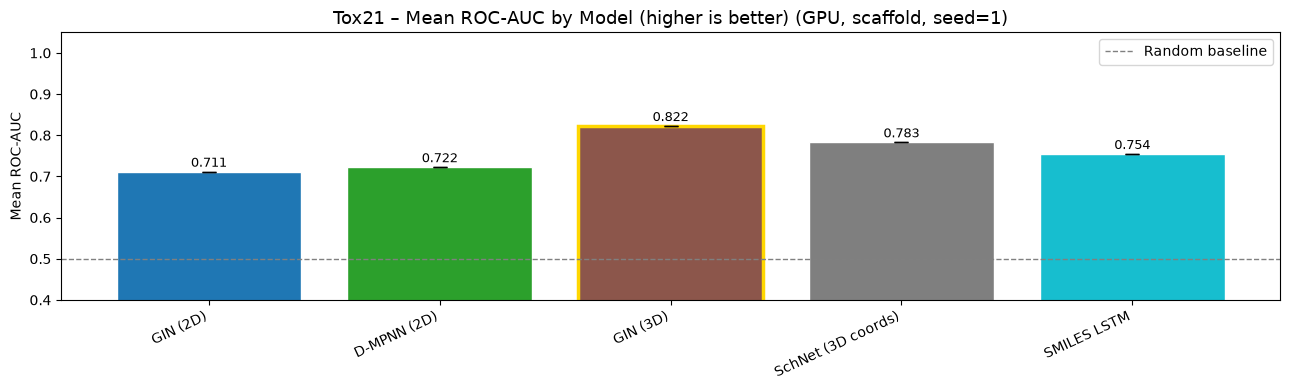

=== TOX21 Results (5/12 models) ===
                            ROC-AUC          PRC-AUC
Model                                               
GIN (2D)            0.7112 ± 0.0000  0.2968 ± 0.0000
D-MPNN (2D)         0.7222 ± 0.0000  0.3210 ± 0.0000
GIN (3D)            0.8222 ± 0.0000  0.4205 ± 0.0000
SchNet (3D coords)  0.7826 ± 0.0000  0.3129 ± 0.0000
SMILES LSTM         0.7542 ± 0.0000  0.3285 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/tox21_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/tox21_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/tox21_partial.json


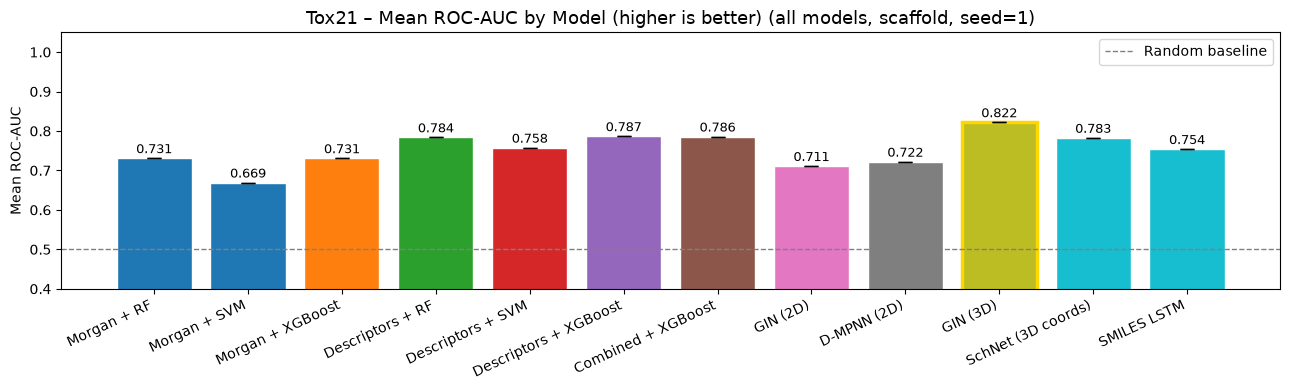

=== TOX21 Results (12/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.7311 ± 0.0000  0.3745 ± 0.0000
Morgan + SVM           0.6692 ± 0.0000  0.2853 ± 0.0000
Morgan + XGBoost       0.7310 ± 0.0000  0.3499 ± 0.0000
Descriptors + RF       0.7840 ± 0.0000  0.4169 ± 0.0000
Descriptors + SVM      0.7576 ± 0.0000  0.3918 ± 0.0000
Descriptors + XGBoost  0.7868 ± 0.0000  0.4135 ± 0.0000
Combined + XGBoost     0.7858 ± 0.0000  0.4249 ± 0.0000
GIN (2D)               0.7112 ± 0.0000  0.2968 ± 0.0000
D-MPNN (2D)            0.7222 ± 0.0000  0.3210 ± 0.0000
GIN (3D)               0.8222 ± 0.0000  0.4205 ± 0.0000
SchNet (3D coords)     0.7826 ± 0.0000  0.3129 ± 0.0000
SMILES LSTM            0.7542 ± 0.0000  0.3285 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/combined/tox21_results.csv
Plot

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"Tox21 – Mean ROC-AUC by Model (higher is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="Mean ROC-AUC", minimize=False)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"Tox21 – Mean ROC-AUC by Model (higher is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="Mean ROC-AUC", minimize=False)
else:
    print("Run CPU notebook first for combined results.")
